In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
df = pd.read_csv("Tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [6]:
df = df[["text", "airline_sentiment"]]

df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [7]:
df.isnull().sum()

,0
text,0
airline_sentiment,0


In [8]:
df = df.dropna()

In [9]:
df["airline_sentiment"].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


In [10]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["airline_sentiment"]
)

In [11]:
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

0 = negative
1 = neutral
2 = positive


In [12]:
X = df["text"].astype(str)

y = df["label"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
vocab_size = 5000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [15]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)

X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [16]:
max_length = 50

X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [17]:
print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (11712, 50)
Testing shape: (2928, 50)


In [18]:
n_classes = y.nunique()

print("Number of classes:", n_classes)

Number of classes: 3


In [19]:
model = Sequential([
    Embedding(
        input_dim=5000,
        output_dim=32
    ),

    SimpleRNN(32),

    Dense(
        n_classes,
        activation="softmax"
    )
])

In [20]:
model.build(input_shape=(None, 50))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,179 (633.51 KB)

 Trainable params: 162,179 (633.51 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6362 - loss: 0.8672 - val_accuracy: 0.6867 - val_loss: 0.7233
Epoch 2/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7024 - loss: 0.6866 - val_accuracy: 0.6974 - val_loss: 0.6787
Epoch 3/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7500 - loss: 0.5860 - val_accuracy: 0.7247 - val_loss: 0.7072
Epoch 4/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7957 - loss: 0.5075 - val_accuracy: 0.7307 - val_loss: 0.8100
Epoch 5/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8255 - loss: 0.4592 - val_accuracy: 0.7367 - val_loss: 0.6866


In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.6885324120521545
Test Accuracy: 0.7336065769195557


In [24]:
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Final Test Accuracy: 73.36%


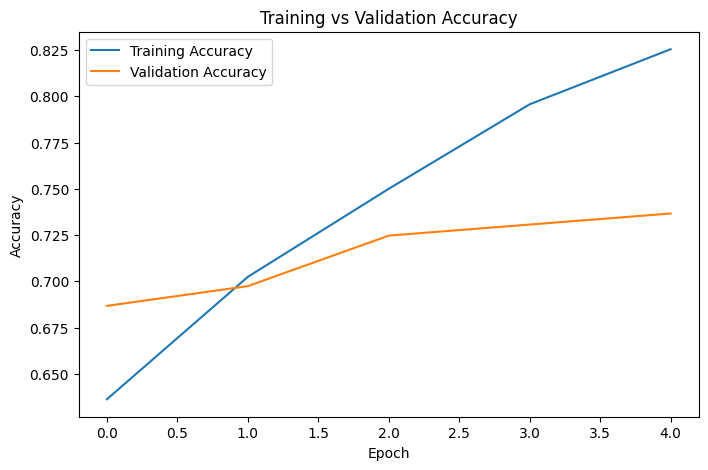

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

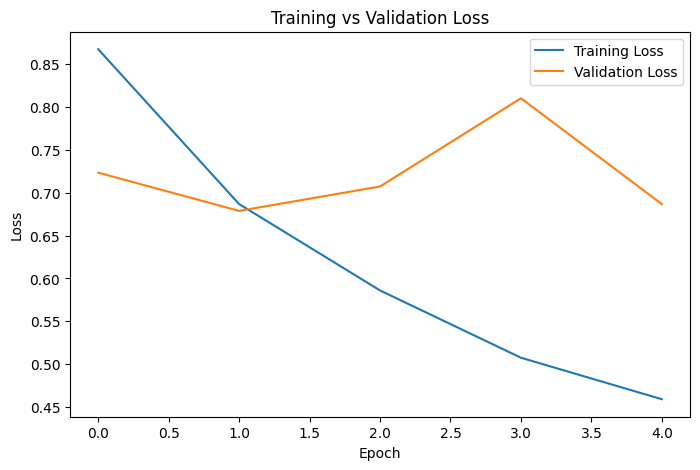

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [27]:
pred_probabilities = model.predict(X_test_pad)

predictions = np.argmax(
    pred_probabilities,
    axis=1
)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [28]:
comparison = pd.DataFrame({
    "Text": X_test.values[:10],
    "Actual": y_test.values[:10],
    "Predicted": predictions[:10]
})

comparison

,Text,Actual,Predicted
0,@united past,1,1
1,@JetBlue would you say a delay is more likely?...,2,2
2,"@JetBlue I cheated on you, and I'm sorry. I'll...",0,0
3,@united disappointed that u didnt honor my $10...,0,0
4,@USAirways The airline is embarrassing itself....,0,0
5,@AmericanAir my flight has been delayed &amp; ...,0,0
6,@united This link in your tweet goes to someon...,1,0
7,@SouthwestAir BETSY is the BESTY! Gettin' stuc...,0,0
8,@USAirways How many agents do you have working...,0,0
9,@SouthwestAir When will the flight resume? I d...,0,1


In [29]:
comparison["Actual Sentiment"] = label_encoder.inverse_transform(
    comparison["Actual"]
)

comparison["Predicted Sentiment"] = label_encoder.inverse_transform(
    comparison["Predicted"]
)

comparison[
    ["Text", "Actual Sentiment", "Predicted Sentiment"]
]

,Text,Actual Sentiment,Predicted Sentiment
0,@united past,neutral,neutral
1,@JetBlue would you say a delay is more likely?...,positive,positive
2,"@JetBlue I cheated on you, and I'm sorry. I'll...",negative,negative
3,@united disappointed that u didnt honor my $10...,negative,negative
4,@USAirways The airline is embarrassing itself....,negative,negative
5,@AmericanAir my flight has been delayed &amp; ...,negative,negative
6,@united This link in your tweet goes to someon...,neutral,negative
7,@SouthwestAir BETSY is the BESTY! Gettin' stuc...,negative,negative
8,@USAirways How many agents do you have working...,negative,negative
9,@SouthwestAir When will the flight resume? I d...,negative,neutral
